# Multi-Target Regressions

This notebook treats the forecasting problem as a multi-target regression task, forecasting all 24-hour prices simultaneously, such as in Bíró et al (2026).

Much of the code is borrowed from Atefeh's "Ati_Catboost" notebook. The feature set was partially modified, and two additional models -- Lasso and XGBoost -- were added.

In [55]:
# Import core libraries 
# =========================================================
import pandas as pd
import numpy as np

# =========================================================
# Import libraries for visualization
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# Import sklearn tools for baseline modeling
# ElasticNet = linear regularized baseline
# MultiOutputRegressor = wraps ElasticNet for 24-output prediction
# Pipeline = combines scaling + model cleanly
# StandardScaler = scales features for linear models
# mean_absolute_error = evaluation metric
# =========================================================
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# =========================================================
# Import Optuna for later hyperparameter tuning
# =========================================================
import optuna

# =========================================================
# Set plotting style for cleaner notebook visuals
# =========================================================
sns.set_style(
    style="darkgrid",
    rc={"axes.facecolor": "white", "grid.color": ".8"}
)

# =========================================================
# Set pandas display options for easier inspection
# =========================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [56]:
# Load the dataset and parse the timestamp column as datetime
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])

# Sort the data chronologically and reset the index
df = df.sort_values("timestamp").reset_index(drop=True)

# Show basic structure
print("Shape:", df.shape)
display(df.head(2))
print(df.columns.tolist())

Shape: (62544, 60)


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,renewable_share,fuel_cost_index,dispatchable_gen,demand_supply_gap,is_peak_hour,wind_x_peak,gas_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,is_negative_price,year,residual_load,load_ramp,renewable_ramp,price_volatility_24h,total_wind_forecast,delta_wind_forecast
0,2019-01-16 00:00:00,29.23,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,22.004999,83.0,35.18,20.04,45.200000,41.705119,22.81,False,False,69793.75,10571.0,13605.00,5162.5,8970.75,3558.75,30280.00,0.0,55014.00,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.450166,46.402999,27738.25,-15498.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,22876.25,-2525.75,-2456.25,9.645450,31418.75,1551.5
1,2019-01-16 01:00:00,29.26,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,22.004999,83.0,35.82,7.24,44.926667,41.836190,22.81,False,False,67991.75,11379.0,13050.75,4994.5,8959.00,3603.00,29191.25,0.0,52838.75,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.449812,46.402999,27004.25,-15541.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,21866.50,-1845.00,-835.25,10.008918,30583.50,510.5


['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'is_negative_price', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'delta_wind_fo

### Create additonal lagged features

In [57]:
# define additional lagged features - similar to Biro et al
df['price_lag_48h'] = df['price_lag_24h'].shift(24)
df['price_lag_72h'] = df['price_lag_24h'].shift(48)
df['total_generation_lag_48h'] = df['total_generation'].shift(48)
df['total_generation_lag_72h'] = df['total_generation'].shift(72)
df['total_generation_lag_168h'] = df['total_generation'].shift(168)
df['net_export_lag_48h'] = df['net_export'].shift(48)
df['net_export_lag_72h'] = df['net_export'].shift(72)
df['net_export_lag_168h'] = df['net_export'].shift(168)
df['gas_price_lag_48h'] = df['gas_price_lag_24h'].shift(24)
df['coal_price_lag_48h'] = df['coal_price_lag_24h'].shift(24)
df['co2_price_lag_48h'] = df['co2_price_lag_24h'].shift(24)

### 3. Data checks

In [58]:
# Check the date range of the dataset
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())

# Check the number of rows and columns
print("Shape:", df.shape)

# Show data types of all columns
#display(df.dtypes)

# Show missing values per column, sorted from highest to lowest
#display(df.isna().sum().sort_values(ascending=False))

Date range: 2019-01-16 00:00:00 to 2026-03-05 23:00:00
Shape: (62544, 71)


In [59]:
# Check whether the timestamp column is strictly increasing
print("Timestamp sorted:", df["timestamp"].is_monotonic_increasing)

# Check the most common time differences between consecutive rows
display(df["timestamp"].diff().value_counts().head())

Timestamp sorted: True


timestamp
0 days 01:00:00    62543
Name: count, dtype: int64

### 4. Inspect the existing structure for daily forecasting

In [60]:
# Check how many rows belong to each calendar day using the timestamp column directly
rows_per_day = df.groupby(df["timestamp"].dt.date).size()

# Show how many days have 24 rows and whether any days are incomplete
display(rows_per_day.value_counts().sort_index())

24    2606
Name: count, dtype: int64

###  5,6. Check duplicate day-hour combinations

In [61]:
# Recreate helper columns directly from the timestamp
df["forecast_date"] = df["timestamp"].dt.floor("D")
df["hour"] = df["timestamp"].dt.hour

# Count duplicate combinations of forecast_date and hour
duplicate_count = df.duplicated(subset=["forecast_date", "hour"]).sum()
print("Number of duplicate day-hour rows:", duplicate_count)

# Show all duplicated rows, if any exist
duplicate_rows = df[df.duplicated(subset=["forecast_date", "hour"], keep=False)].copy()

# Sort for easier inspection
duplicate_rows = duplicate_rows.sort_values(["forecast_date", "hour", "timestamp"])

# Display a compact view
display(duplicate_rows[["timestamp", "forecast_date", "hour", "price"]].head(50))

Number of duplicate day-hour rows: 0


,timestamp,forecast_date,hour,price


### 7. Create the 24-hour target matrix
this converts hourly prices into one row per day. each row now has 24 target values
this is Y for multi-output forecasting


We do a **multi-output forecast**. We reshape the target matrix to have shape \((N, 24)\) and wrap the model with `MultiOutputRegressor`. In practice, this means that **24 separate models** are trained, one for each forecast hour. So the model predicts the full next-day price curve, but it does **not** learn the dependencies between the 24 hours jointly.

In [62]:
# Create a daily datetime column for reshaping
df["forecast_date"] = df["timestamp"].dt.floor("D")

# Reshape hourly prices into one row per day and 24 price columns
target_wide = df.pivot(index="forecast_date", columns="hour", values="price")

# Rename the target columns clearly as price_h00 to price_h23
target_wide.columns = [f"price_h{hour:02d}" for hour in target_wide.columns]

# Sort the target matrix by day
target_wide = target_wide.sort_index()

# Show the result
print(target_wide.shape)
display(target_wide.head())

(2606, 24)


,price_h00,price_h01,price_h02,price_h03,price_h04,price_h05,price_h06,price_h07,price_h08,price_h09,price_h10,price_h11,price_h12,price_h13,price_h14,price_h15,price_h16,price_h17,price_h18,price_h19,price_h20,price_h21,price_h22,price_h23
forecast_date,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-16,29.23,29.26,32.64,32.41,33.06,33.22,46.63,53.80,55.73,53.83,54.22,54.92,53.65,52.69,53.55,53.72,54.83,54.01,52.67,50.92,39.81,39.29,39.91,30.77
2019-01-17,26.35,25.23,22.77,24.02,25.63,28.06,35.38,46.04,49.96,50.56,46.10,46.02,43.94,46.64,55.00,55.90,57.43,58.72,55.06,53.85,49.52,42.35,42.44,41.11
2019-01-18,42.26,40.91,43.77,45.05,47.89,49.79,54.77,73.08,76.86,74.32,70.51,69.02,68.94,65.27,67.44,68.14,69.00,75.04,76.13,72.46,61.83,59.24,56.70,53.16
2019-01-19,52.47,53.18,54.73,51.15,52.25,50.93,49.04,50.56,55.71,56.62,63.13,57.33,55.26,54.38,52.55,55.41,62.93,67.15,68.91,57.37,54.61,52.32,51.53,49.80
2019-01-20,47.74,47.01,48.80,48.90,49.63,49.53,46.69,46.76,50.88,52.38,50.07,49.33,48.98,47.40,53.20,55.39,58.02,66.68,69.43,69.75,67.83,57.37,59.56,52.07


### 34. Define the daily feature design 

The target of the model is a **24-dimensional daily price vector**, so one row of the input should also describe the forecast day more completely.

For this reason, the daily feature matrix is rebuilt in two parts:

- **daily scalar features**, which appear once per day
- **hourly block features**, which are reshaped into 24 hour-specific columns

This means that instead of keeping only one hourly value per day, the model receives the **full 24-hour profile** of selected inputs such as lagged prices, load, wind, and solar.

This is important because the model is trained for a **multi-output forecast**:
$$
\hat{\mathbf{Y}}_d = \left[\hat{Y}_d^{1}, \hat{Y}_d^{2}, \dots, \hat{Y}_d^{24}\right]
$$

So the input representation should also better reflect the daily structure of the forecasting problem.

In [63]:
# Define hourly features that should enter as 24-hour blocks
hourly_block_features = [
    "price_lag_24h",
    "price_lag_48h",
    "price_lag_72h",
    "price_lag_168h",
    "price_volatility_24h",
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "net_export_lag_48h",
    "net_export_lag_72h",
    "net_export_lag_168h",
    "total_generation_lag_48h",
    "total_generation_lag_72h",
    "total_generation_lag_168h",
    "load_ramp",
    "renewable_ramp",
    "temperature",
    "wind_speed",
    "delta_wind_forecast"
]

# Define daily scalar features that enter once per day
daily_scalar_features = [
    "is_weekend",
    "is_holiday",
    "gas_price_lag_48h",
    "coal_price_lag_48h",
    "co2_price_lag_48h",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "is_high_price_regime"
]

# Show both feature groups
print("Hourly block features:", hourly_block_features)
print("Daily scalar features:", daily_scalar_features)

Hourly block features: ['price_lag_24h', 'price_lag_48h', 'price_lag_72h', 'price_lag_168h', 'price_volatility_24h', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'net_export_lag_48h', 'net_export_lag_72h', 'net_export_lag_168h', 'total_generation_lag_48h', 'total_generation_lag_72h', 'total_generation_lag_168h', 'load_ramp', 'renewable_ramp', 'temperature', 'wind_speed', 'delta_wind_forecast']
Daily scalar features: ['is_weekend', 'is_holiday', 'gas_price_lag_48h', 'coal_price_lag_48h', 'co2_price_lag_48h', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_high_price_regime']


### 35. Construct the daily feature matrix


After defining the hourly block features and daily scalar features, the new daily input matrix is constructed.

First, each row is assigned to a forecast day and an hour.  
Then, the hourly block features are reshaped from long hourly format into wide daily format, so that each selected feature contributes 24 hour-specific columns.

At the same time, the daily scalar features are kept once per day.

Finally, both parts are concatenated into a new daily feature matrix:

$$
\mathbf{X}_d = \left[\mathbf{X}_{d,\mathrm{scalar}}, \mathbf{X}_{d,\mathrm{block}}\right]
$$

This yields a richer day-level representation that is better suited for forecasting the 24-hour target vector.

In [64]:
# Create a daily datetime column for grouping
df["forecast_date"] = df["timestamp"].dt.floor("D")

# Recreate the hour column directly from the timestamp
df["hour"] = df["timestamp"].dt.hour

# Reshape the hourly block features into daily wide format
X_blocks = df.pivot(index="forecast_date", columns="hour", values=hourly_block_features)

# Flatten the multi-level column names
X_blocks.columns = [f"{feature}_h{hour:02d}" for feature, hour in X_blocks.columns]

# Keep one row per day for the daily scalar features
X_scalars = df.groupby("forecast_date")[daily_scalar_features].first()

# Combine daily scalar features and hourly block features
X_daily = pd.concat([X_scalars, X_blocks], axis=1).sort_index()

# Drop NaN - some created by generating new lagged variables
X_daily = X_daily.dropna()

# Show the result
print("X_daily shape:", X_daily.shape)
display(X_daily.head())

X_daily shape: (2599, 490)


,is_weekend,is_holiday,gas_price_lag_48h,coal_price_lag_48h,co2_price_lag_48h,month_sin,month_cos,dow_sin,dow_cos,is_high_price_regime,price_lag_24h_h00,price_lag_24h_h01,price_lag_24h_h02,price_lag_24h_h03,price_lag_24h_h04,price_lag_24h_h05,price_lag_24h_h06,price_lag_24h_h07,price_lag_24h_h08,price_lag_24h_h09,price_lag_24h_h10,price_lag_24h_h11,price_lag_24h_h12,price_lag_24h_h13,price_lag_24h_h14,price_lag_24h_h15,price_lag_24h_h16,price_lag_24h_h17,price_lag_24h_h18,price_lag_24h_h19,price_lag_24h_h20,price_lag_24h_h21,price_lag_24h_h22,price_lag_24h_h23,price_lag_48h_h00,price_lag_48h_h01,price_lag_48h_h02,price_lag_48h_h03,price_lag_48h_h04,price_lag_48h_h05,price_lag_48h_h06,price_lag_48h_h07,price_lag_48h_h08,price_lag_48h_h09,price_lag_48h_h10,price_lag_48h_h11,price_lag_48h_h12,price_lag_48h_h13,price_lag_48h_h14,price_lag_48h_h15,price_lag_48h_h16,price_lag_48h_h17,price_lag_48h_h18,price_lag_48h_h19,price_lag_48h_h20,price_lag_48h_h21,price_lag_48h_h22,price_lag_48h_h23,price_lag_72h_h00,price_lag_72h_h01,price_lag_72h_h02,price_lag_72h_h03,price_lag_72h_h04,price_lag_72h_h05,price_lag_72h_h06,price_lag_72h_h07,price_lag_72h_h08,price_lag_72h_h09,price_lag_72h_h10,price_lag_72h_h11,price_lag_72h_h12,price_lag_72h_h13,price_lag_72h_h14,price_lag_72h_h15,price_lag_72h_h16,price_lag_72h_h17,price_lag_72h_h18,price_lag_72h_h19,price_lag_72h_h20,price_lag_72h_h21,price_lag_72h_h22,price_lag_72h_h23,price_lag_168h_h00,price_lag_168h_h01,price_lag_168h_h02,price_lag_168h_h03,price_lag_168h_h04,price_lag_168h_h05,price_lag_168h_h06,price_lag_168h_h07,price_lag_168h_h08,price_lag_168h_h09,price_lag_168h_h10,price_lag_168h_h11,price_lag_168h_h12,price_lag_168h_h13,price_lag_168h_h14,price_lag_168h_h15,price_lag_168h_h16,price_lag_168h_h17,price_lag_168h_h18,price_lag_168h_h19,price_lag_168h_h20,price_lag_168h_h21,price_lag_168h_h22,price_lag_168h_h23,price_volatility_24h_h00,price_volatility_24h_h01,price_volatility_24h_h02,price_volatility_24h_h03,price_volatility_24h_h04,price_volatility_24h_h05,price_volatility_24h_h06,price_volatility_24h_h07,price_volatility_24h_h08,price_volatility_24h_h09,price_volatility_24h_h10,price_volatility_24h_h11,price_volatility_24h_h12,price_volatility_24h_h13,price_volatility_24h_h14,price_volatility_24h_h15,price_volatility_24h_h16,price_volatility_24h_h17,price_volatility_24h_h18,price_volatility_24h_h19,price_volatility_24h_h20,price_volatility_24h_h21,price_volatility_24h_h22,price_volatility_24h_h23,load_h00,load_h01,load_h02,load_h03,load_h04,load_h05,load_h06,load_h07,load_h08,load_h09,load_h10,load_h11,load_h12,load_h13,load_h14,load_h15,load_h16,load_h17,load_h18,load_h19,load_h20,load_h21,load_h22,load_h23,wind_offshore_h00,wind_offshore_h01,wind_offshore_h02,wind_offshore_h03,wind_offshore_h04,wind_offshore_h05,wind_offshore_h06,wind_offshore_h07,wind_offshore_h08,wind_offshore_h09,wind_offshore_h10,wind_offshore_h11,wind_offshore_h12,wind_offshore_h13,wind_offshore_h14,wind_offshore_h15,wind_offshore_h16,wind_offshore_h17,wind_offshore_h18,wind_offshore_h19,wind_offshore_h20,wind_offshore_h21,wind_offshore_h22,wind_offshore_h23,wind_onshore_h00,wind_onshore_h01,wind_onshore_h02,wind_onshore_h03,wind_onshore_h04,wind_onshore_h05,wind_onshore_h06,wind_onshore_h07,wind_onshore_h08,wind_onshore_h09,wind_onshore_h10,wind_onshore_h11,wind_onshore_h12,wind_onshore_h13,wind_onshore_h14,wind_onshore_h15,wind_onshore_h16,wind_onshore_h17,wind_onshore_h18,wind_onshore_h19,wind_onshore_h20,wind_onshore_h21,wind_onshore_h22,wind_onshore_h23,solar_h00,solar_h01,solar_h02,solar_h03,solar_h04,solar_h05,solar_h06,solar_h07,solar_h08,solar_h09,solar_h10,solar_h11,solar_h12,solar_h13,solar_h14,solar_h15,solar_h16,solar_h17,solar_h18,solar_h19,solar_h20,solar_h21,solar_h22,solar_h23,net_export_lag_48h_h00,net_export_lag_48h_h01,net_export_lag_48h_h02,net_export_lag_48h_h03,net_export_lag_48h_h04,net_export_lag_48h_h05,net_export_lag_48h_h06,net_export_lag_48h_h07,net_export_lag_48h_h08,net_export

### Align the daily feature matrix and target matrix 
This makes sure X and Y refer to the same forecast days after this, we have the basic daily modeling tables ready

In [65]:
# Keep only dates that exist in both X and Y
common_dates = X_daily.index.intersection(target_wide.index)

# Align X and Y to the same daily index
X_daily = X_daily.loc[common_dates].sort_index()
Y_daily = target_wide.loc[common_dates].sort_index()

# Check the final shapes
print("X_daily shape:", X_daily.shape)
print("Y_daily shape:", Y_daily.shape)

# Check whether both indices are identical
print("Indices match:", X_daily.index.equals(Y_daily.index))

X_daily shape: (2599, 490)
Y_daily shape: (2599, 24)
Indices match: True


### 37. Split test/train: Create the chronological split for the daily feature matrix

In [66]:
# Split the feature matrix into train, validation, and test sets
X_train = X_daily[X_daily.index < "2025-01-01"].copy()
X_val = X_daily[(X_daily.index >= "2025-01-01") & (X_daily.index < "2025-07-01")].copy()
X_test = X_daily[X_daily.index >= "2025-07-01"].copy()

# Split the aligned target matrix into train, validation, and test sets
Y_train = Y_daily[Y_daily.index < "2025-01-01"].copy()
Y_val = Y_daily[(Y_daily.index >= "2025-01-01") & (Y_daily.index < "2025-07-01")].copy()
Y_test = Y_daily[Y_daily.index >= "2025-07-01"].copy()

# Show the resulting shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Y_test:", Y_test.shape)

X_train: (2170, 490)
X_val: (181, 490)
X_test: (248, 490)
Y_train: (2170, 24)
Y_val: (181, 24)
Y_test: (248, 24)


### 38. Create training sample weights

In [67]:
# Create a weight series with default weight 1.0 for all training days
train_weights = pd.Series(1.0, index=X_train.index)

# Downweight the pre-crisis period
train_weights.loc[(train_weights.index >= "2019-01-01") & (train_weights.index < "2021-01-01")] = 0.6

# Downweight the crisis period more strongly
train_weights.loc[(train_weights.index >= "2021-01-01") & (train_weights.index < "2023-01-01")] = 0.3

# Keep full weight for the post-crisis period inside training
train_weights.loc[(train_weights.index >= "2023-01-01") & (train_weights.index < "2025-01-01")] = 1.0

# Show how many days fall into each weight group
display(train_weights.value_counts().sort_index())

# Show the first rows
display(train_weights.head())

0.3    730
0.6    709
1.0    731
Name: count, dtype: int64

forecast_date
2019-01-23    0.6
2019-01-24    0.6
2019-01-25    0.6
2019-01-26    0.6
2019-01-27    0.6
dtype: float64

### 13. Build the naive baseline

$$
    \mathbf{y}_{d}=
\begin{cases}
\mathbf{y}_{d-1}, & \text{if } d \in \{\text{Tue, Wed, Thu, Fri, Sun}\} \\
\mathbf{y}_{d-7}, & \text{if } d \in \{\text{Mon, Sat}\}
\end{cases}
$$

In [68]:
# Define a function for the naive daily 24-hour forecast
def predict_price_lag_daily(y_daily):
    # Create an empty DataFrame with the same index and columns as the target
    y_pred = pd.DataFrame(index=y_daily.index, columns=y_daily.columns, dtype=float)

    # Loop over each forecast day
    for day in y_daily.index:
        # Get the weekday of the forecast day
        day_of_week = day.dayofweek

        # Use D-1 for Tue, Wed, Thu, Fri, Sun
        if day_of_week in {1, 2, 3, 4, 6}:
            ref_day = day - pd.Timedelta(days=1)
        # Use D-7 for Mon and Sat
        else:
            ref_day = day - pd.Timedelta(days=7)

        # Copy the full 24-hour curve if the reference day exists
        if ref_day in y_daily.index:
            y_pred.loc[day] = y_daily.loc[ref_day].values

    # Return the naive prediction matrix
    return y_pred

# Create naive predictions for all available days
Y_pred_naive = predict_price_lag_daily(Y_daily)

### 13b. Plot actual vs. naive forecast for one example day

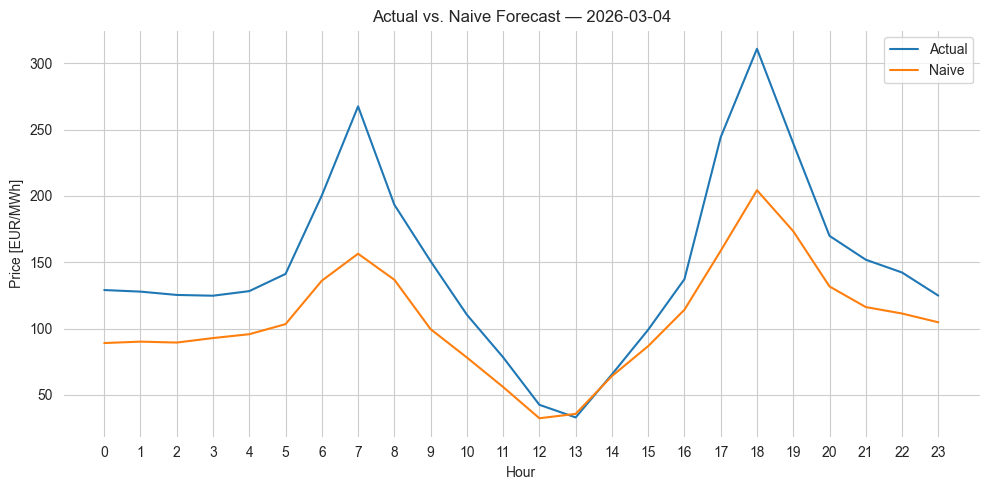

In [69]:
# Select one day for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual and naive values for that day
plot_df = pd.DataFrame({
    "actual": Y_daily.loc[day].values,
    "naive": Y_pred_naive.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual and naive hourly prices
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual")
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Actual vs. Naive Forecast — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 14. Define the evaluation metrics
mae_24 measures hourly forecast error over all 24 outputs
dae measures how well the daily average price level is captured
rmae compares a model against the naive baseline

$$
\mathrm{MAE} = \frac{1}{N \cdot 24} \sum_{d=1}^{N} \sum_{h=1}^{24} \left| y_{d,h} - \hat{y}_{d,h} \right|
$$

$$
\mathrm{DAE} = \frac{1}{N} \sum_{d=1}^{N} \left| \frac{1}{24}\sum_{h=1}^{24} y_{d,h} - \frac{1}{24}\sum_{h=1}^{24} \hat{y}_{d,h} \right|
$$

$$
\mathrm{RMAE} = \frac{\mathrm{MAE}_{\mathrm{model}}}{\mathrm{MAE}_{\mathrm{naive}}}
$$

In [70]:
# Define MAE over all predicted hourly values
def mae_24(y_true, y_pred):
    # Flatten both matrices and compute the mean absolute error
    return mean_absolute_error(y_true.values.ravel(), y_pred.values.ravel())

# Define DAE based on the daily average price level
def dae(y_true, y_pred):
    # Compute the daily mean price from the 24 hourly values
    true_daily_mean = y_true.mean(axis=1)
    pred_daily_mean = y_pred.mean(axis=1)
    
    # Compute the mean absolute difference between daily average prices
    return np.mean(np.abs(true_daily_mean - pred_daily_mean))

# Define RMAE relative to the naive baseline
def rmae(model_mae, naive_mae):
    # Compare model MAE to naive MAE
    return model_mae / naive_mae

### 15. Evaluate the naive baseline on validation and test

In [71]:
# Create naive predictions for the validation period
Y_val_naive = Y_pred_naive.loc[Y_val.index].copy()

# Create naive predictions for the test period
Y_test_naive = Y_pred_naive.loc[Y_test.index].copy()

# Compute naive validation metrics
naive_val_mae = mae_24(Y_val, Y_val_naive)
naive_val_dae = dae(Y_val, Y_val_naive)

# Compute naive test metrics
naive_test_mae = mae_24(Y_test, Y_test_naive)
naive_test_dae = dae(Y_test, Y_test_naive)

# Print validation results
print("Naive validation MAE:", round(naive_val_mae, 4))
print("Naive validation DAE:", round(naive_val_dae, 4))

# Print test results
print("Naive test MAE:", round(naive_test_mae, 4))
print("Naive test DAE:", round(naive_test_dae, 4))

Naive validation MAE: 28.4164
Naive validation DAE: 22.57
Naive test MAE: 23.3474
Naive test DAE: 18.8407


----------------------------------------------------------------------------------------------------------------

### Build the LASSO baseline

In [72]:
# Build a pipeline with feature scaling and Lasso
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        Lasso(alpha=0.1, max_iter=10000, random_state=42)
    ))
])

# Fit the Lasso model on the daily feature matrix using training data and sample weights
lasso.fit(X_train, Y_train, model__sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_lasso = pd.DataFrame(
    lasso.predict(X_val),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_lasso = pd.DataFrame(
    lasso.predict(X_test),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_lasso.shape)
print("Test prediction shape:", Y_test_pred_lasso.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### Evaluate the Lasso baseline

In [73]:
# Compute validation metrics for Lasso
lasso_val_mae = mae_24(Y_val, Y_val_pred_lasso)
lasso_val_dae = dae(Y_val, Y_val_pred_lasso)
lasso_val_rmae = rmae(lasso_val_mae, naive_val_mae)

# Compute test metrics for Lasso
lasso_test_mae = mae_24(Y_test, Y_test_pred_lasso)
lasso_test_dae = dae(Y_test, Y_test_pred_lasso)
lasso_test_rmae = rmae(lasso_test_mae, naive_test_mae)

# Print validation results
print("Lasso - validation MAE:", round(lasso_val_mae, 4))
print("Lasso - validation DAE:", round(lasso_val_dae, 4))
print("Lasso - validation RMAE:", round(lasso_val_rmae, 4))

# Print test results
print("Lasso - test MAE:", round(lasso_test_mae, 4))
print("Lasso - test DAE:", round(lasso_test_dae, 4))
print("Lasso - test RMAE:", round(lasso_test_rmae, 4))

Lasso - validation MAE: 11.6993
Lasso - validation DAE: 6.6732
Lasso - validation RMAE: 0.4117
Lasso - test MAE: 11.4948
Lasso - test DAE: 7.7512
Lasso - test RMAE: 0.4923


----------------------------------------------------------------------------------------------------------------

### 39. Build the ElasticNet baseline

In [74]:
# Build a pipeline with feature scaling and ElasticNet
elasticnet = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(
        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42)
    ))
])

# Fit the ElasticNet model on the daily feature matrix using training data and sample weights
elasticnet.fit(X_train, Y_train, model__sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_enet = pd.DataFrame(
    elasticnet.predict(X_val),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_enet = pd.DataFrame(
    elasticnet.predict(X_test),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_enet.shape)
print("Test prediction shape:", Y_test_pred_enet.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 40. Evaluate the ElasticNet baseline

In [75]:
# Compute validation metrics for ElasticNet
enet_val_mae = mae_24(Y_val, Y_val_pred_enet)
enet_val_dae = dae(Y_val, Y_val_pred_enet)
enet_val_rmae = rmae(enet_val_mae, naive_val_mae)

# Compute test metrics for ElasticNet
enet_test_mae = mae_24(Y_test, Y_test_pred_enet)
enet_test_dae = dae(Y_test, Y_test_pred_enet)
enet_test_rmae = rmae(enet_test_mae, naive_test_mae)

# Print validation results
print("ElasticNet - validation MAE:", round(enet_val_mae, 4))
print("ElasticNet - validation DAE:", round(enet_val_dae, 4))
print("ElasticNet - validation RMAE:", round(enet_val_rmae, 4))

# Print test results
print("ElasticNet - test MAE:", round(enet_test_mae, 4))
print("ElasticNet - test DAE:", round(enet_test_dae, 4))
print("ElasticNet - test RMAE:", round(enet_test_rmae, 4))

ElasticNet - validation MAE: 12.8697
ElasticNet - validation DAE: 6.8064
ElasticNet - validation RMAE: 0.4529
ElasticNet - test MAE: 12.6111
ElasticNet - test DAE: 8.1787
ElasticNet - test RMAE: 0.5401


### 41b. Plot actual, ElasticNet, and Lasso forecast for one example day

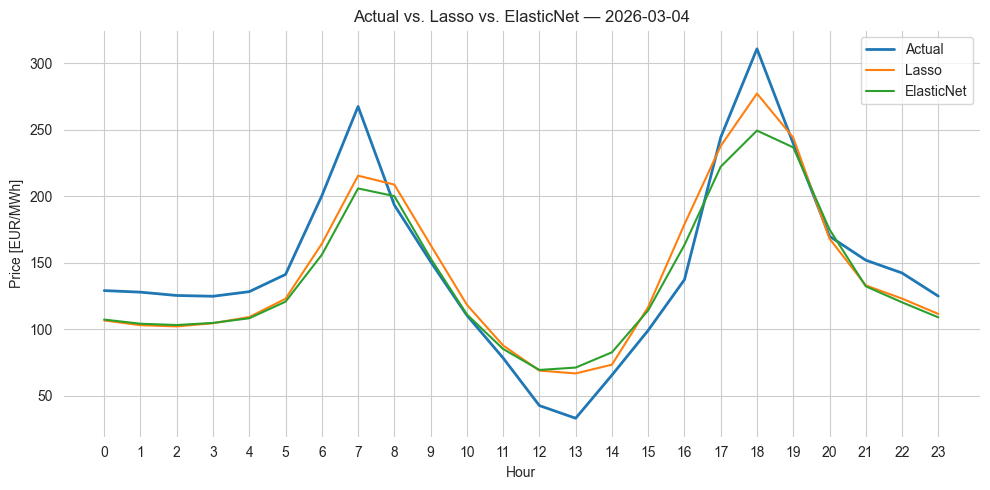

In [76]:
# Select one day from the test set for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual values, Lasso and ElasticNet predictions for that day
plot_df = pd.DataFrame({
    "actual": Y_test.loc[day].values,
    "Lasso": Y_test_pred_lasso.loc[day].values,
    "ElasticNet": Y_test_pred_enet.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual values and ElasticNet v2 forecast
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["Lasso"], label="Lasso")
plt.plot(plot_df["hour"], plot_df["ElasticNet"], label="ElasticNet")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Actual vs. Lasso vs. ElasticNet — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------------

### Build the XGBoost baseline

In [77]:
# Import XGBRegressor
from xgboost import XGBRegressor

In [78]:
X_train.shape

(2170, 490)

In [79]:
xgboost = MultiOutputRegressor(XGBRegressor(
            objective="reg:pseudohubererror",
            eval_metric="mae",
            n_estimators=800,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=42
        )
)

# Fit the XGBoost model using training data and sample weights
xgboost.fit(X_train, Y_train, sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_xgb = pd.DataFrame(
    xgboost.predict(X_val),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_xgb = pd.DataFrame(
    xgboost.predict(X_test),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_xgb.shape)
print("Test prediction shape:", Y_test_pred_xgb.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


In [80]:
print(Y_val_pred_xgb.mean(), Y_val.mean())
print(Y_val_pred_xgb.std(), Y_val.std())

price_h00     94.304695
price_h01     87.683121
price_h02     83.791985
price_h03     82.405663
price_h04     82.369446
price_h05     90.584824
price_h06    107.911171
price_h07    117.444221
price_h08    113.702759
price_h09     93.108757
price_h10     75.026085
price_h11     62.500217
price_h12     55.335094
price_h13     50.316380
price_h14     51.732815
price_h15     62.532574
price_h16     78.323288
price_h17    105.216927
price_h18    316.055725
price_h19    766.728271
price_h20    468.774200
price_h21    333.966553
price_h22    222.483917
price_h23     95.535004
dtype: float32 price_h00     94.899227
price_h01     89.189890
price_h02     86.510939
price_h03     85.158895
price_h04     86.743646
price_h05     92.933315
price_h06    107.945746
price_h07    119.187956
price_h08    114.166906
price_h09     89.578287
price_h10     66.875028
price_h11     53.013039
price_h12     42.988619
price_h13     37.036243
price_h14     40.771160
price_h15     56.190000
price_h16     74.386133
p

### Evaluate the XGBoost baseline

In [81]:
# Compute validation metrics for XGBoost
xgb_val_mae = mae_24(Y_val, Y_val_pred_xgb)
xgb_val_dae = dae(Y_val, Y_val_pred_xgb)
xgb_val_rmae = rmae(xgb_val_mae, naive_val_mae)

# Compute test metrics for XGBoost
xgb_test_mae = mae_24(Y_test, Y_test_pred_xgb)
xgb_test_dae = dae(Y_test, Y_test_pred_xgb)
xgb_test_rmae = rmae(xgb_test_mae, naive_test_mae)

# Print validation results
print("XGBoost - validation MAE:", round(xgb_val_mae, 4))
print("XGBoost - validation DAE:", round(xgb_val_dae, 4))
print("XGBoost - validation RMAE:", round(xgb_val_rmae, 4))

# Print test results
print("XGBoost - test MAE:", round(xgb_test_mae, 4))
print("XGBoost - test DAE:", round(xgb_test_dae, 4))
print("XGBoost - test RMAE:", round(xgb_test_rmae, 4))

XGBoost - validation MAE: 72.8567
XGBoost - validation DAE: 64.0185
XGBoost - validation RMAE: 2.5639
XGBoost - test MAE: 72.8024
XGBoost - test DAE: 60.6664
XGBoost - test RMAE: 3.1182


----------------------------------------------------------------------------------------------------------------

### 42. Build the CatBoost baseline

In [82]:
# Import CatBoostRegressor for tree-based regression
from catboost import CatBoostRegressor

In [83]:
# Build a CatBoost model
catboost = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42
    )
)

# Fit the CatBoost model using training data and sample weights
catboost.fit(X_train, Y_train, sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_cat = pd.DataFrame(
    catboost.predict(X_val),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_cat = pd.DataFrame(
    catboost.predict(X_test),
    index=Y_test.index,
    columns=Y_test.columns
)

# Show the shapes of the prediction matrices
print("Validation prediction shape:", Y_val_pred_cat.shape)
print("Test prediction shape:", Y_test_pred_cat.shape)

Validation prediction shape: (181, 24)
Test prediction shape: (248, 24)


### 43. Evaluate the CatBoost baseline

In [84]:
# Compute validation metrics for CatBoost
cat_val_mae = mae_24(Y_val, Y_val_pred_cat)
cat_val_dae = dae(Y_val, Y_val_pred_cat)
cat_val_rmae = rmae(cat_val_mae, naive_val_mae)

# Compute test metrics for CatBoost
cat_test_mae = mae_24(Y_test, Y_test_pred_cat)
cat_test_dae = dae(Y_test, Y_test_pred_cat)
cat_test_rmae = rmae(cat_test_mae, naive_test_mae)

# Print validation results
print("CatBoost - validation MAE:", round(cat_val_mae, 4))
print("CatBoost - validation DAE:", round(cat_val_dae, 4))
print("CatBoost - validation RMAE:", round(cat_val_rmae, 4))

# Print test results
print("CatBoost - test MAE:", round(cat_test_mae, 4))
print("CatBoost - test DAE:", round(cat_test_dae, 4))
print("CatBoost - test RMAE:", round(cat_test_rmae, 4))

CatBoost - validation MAE: 14.5534
CatBoost - validation DAE: 9.0873
CatBoost - validation RMAE: 0.5121
CatBoost - test MAE: 11.4157
CatBoost - test DAE: 6.3138
CatBoost - test RMAE: 0.4889


### 45a. Check the daily feature matrix before CatBoost tuning

In [85]:
# Check data types in the training feature matrix
display(X_train.dtypes.value_counts())

# Check missing values per column
missing = X_train.isna().sum().sort_values(ascending=False)

# Show only columns with missing values
display(missing[missing > 0].head(20))

# Check whether the target has missing values
print("Missing values in Y_train:", Y_train.isna().sum().sum())

float64    488
bool         2
Name: count, dtype: int64

Series([], dtype: int64)

Missing values in Y_train: 0


### 45. Simple hyperparameter tuning for CatBoost with error handling

In [86]:
# Define a small grid of CatBoost hyperparameters
depth_grid = [4, 6, 8]
learning_rate_grid = [0.03, 0.05, 0.1]
iterations_grid = [200, 300, 500]

# Store successful results
tuning_results_cat = []

# Loop over all parameter combinations
for depth in depth_grid:
    for learning_rate in learning_rate_grid:
        for iterations in iterations_grid:
            try:
                # Print the current combination
                print(f"Running depth={depth}, learning_rate={learning_rate}, iterations={iterations}")

                # Build the CatBoost model
                model = MultiOutputRegressor(
                    CatBoostRegressor(
                        iterations=iterations,
                        depth=depth,
                        learning_rate=learning_rate,
                        loss_function="MAE",
                        eval_metric="MAE",
                        verbose=0,
                        random_state=42
                    )
                )

                # Fit the model
                model.fit(X_train, Y_train, sample_weight=train_weights)

                # Predict on validation data
                Y_val_pred = pd.DataFrame(
                    model.predict(X_val),
                    index=Y_val.index,
                    columns=Y_val.columns
                )

                # Compute validation metrics
                val_mae = mae_24(Y_val, Y_val_pred)
                val_dae = dae(Y_val, Y_val_pred)
                val_rmae = rmae(val_mae, naive_val_mae)

                # Store the result
                tuning_results_cat.append({
                    "depth": depth,
                    "learning_rate": learning_rate,
                    "iterations": iterations,
                    "val_MAE": val_mae,
                    "val_DAE": val_dae,
                    "val_RMAE": val_rmae
                })

            except Exception as e:
                print(f"FAILED: depth={depth}, learning_rate={learning_rate}, iterations={iterations}")
                print(repr(e))

# Convert results to a DataFrame
tuning_results_cat = pd.DataFrame(tuning_results_cat)

# Sort by validation MAE
tuning_results_cat = tuning_results_cat.sort_values("val_MAE").reset_index(drop=True)

# Show the best combinations
display(tuning_results_cat.head(10).round(4))

Running depth=4, learning_rate=0.03, iterations=200
Running depth=4, learning_rate=0.03, iterations=300
Running depth=4, learning_rate=0.03, iterations=500
Running depth=4, learning_rate=0.05, iterations=200
Running depth=4, learning_rate=0.05, iterations=300
Running depth=4, learning_rate=0.05, iterations=500
Running depth=4, learning_rate=0.1, iterations=200
Running depth=4, learning_rate=0.1, iterations=300
Running depth=4, learning_rate=0.1, iterations=500
Running depth=6, learning_rate=0.03, iterations=200
Running depth=6, learning_rate=0.03, iterations=300
Running depth=6, learning_rate=0.03, iterations=500
Running depth=6, learning_rate=0.05, iterations=200
Running depth=6, learning_rate=0.05, iterations=300
Running depth=6, learning_rate=0.05, iterations=500
Running depth=6, learning_rate=0.1, iterations=200
Running depth=6, learning_rate=0.1, iterations=300
Running depth=6, learning_rate=0.1, iterations=500
Running depth=8, learning_rate=0.03, iterations=200
Running depth=8, l

,depth,learning_rate,iterations,val_MAE,val_DAE,val_RMAE
0,4,0.03,500,13.8640,8.8084,0.4879
1,4,0.05,500,13.8928,8.2944,0.4889
2,6,0.03,500,14.1199,8.7933,0.4969
3,4,0.05,300,14.2981,8.7486,0.5032
4,6,0.05,500,14.3625,8.8262,0.5054
5,6,0.05,300,14.5534,9.0873,0.5121
6,4,0.03,300,14.6537,9.6456,0.5157
7,6,0.03,300,14.6547,9.4362,0.5157
8,4,0.10,500,14.7386,8.9595,0.5187
9,4,0.05,200,14.8376,9.3542,0.5221


### 46. Refit the best CatBoost model

In [87]:
# Set the best CatBoost hyperparameters from the tuning results
best_depth = 6
best_learning_rate = 0.03
best_iterations = 500

# Build the tuned CatBoost model
catboost_tuned = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=best_iterations,
        depth=best_depth,
        learning_rate=best_learning_rate,
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42
    )
)

# Fit the tuned CatBoost model
catboost_tuned.fit(X_train, Y_train, sample_weight=train_weights)

# Predict on the validation set
Y_val_pred_cat_tuned = pd.DataFrame(
    catboost_tuned.predict(X_val),
    index=Y_val.index,
    columns=Y_val.columns
)

# Predict on the test set
Y_test_pred_cat_tuned = pd.DataFrame(
    catboost_tuned.predict(X_test),
    index=Y_test.index,
    columns=Y_test.columns
)

### 47. Evaluate the tuned CatBoost model

In [88]:
# Compute validation metrics for the tuned CatBoost model
cat_tuned_val_mae = mae_24(Y_val, Y_val_pred_cat_tuned)
cat_tuned_val_dae = dae(Y_val, Y_val_pred_cat_tuned)
cat_tuned_val_rmae = rmae(cat_tuned_val_mae, naive_val_mae)

# Compute test metrics for the tuned CatBoost model
cat_tuned_test_mae = mae_24(Y_test, Y_test_pred_cat_tuned)
cat_tuned_test_dae = dae(Y_test, Y_test_pred_cat_tuned)
cat_tuned_test_rmae = rmae(cat_tuned_test_mae, naive_test_mae)

# Print validation results
print("CatBoost tuned - validation MAE:", round(cat_tuned_val_mae, 4))
print("CatBoost tuned - validation DAE:", round(cat_tuned_val_dae, 4))
print("CatBoost tuned - validation RMAE:", round(cat_tuned_val_rmae, 4))

# Print test results
print("CatBoost tuned - test MAE:", round(cat_tuned_test_mae, 4))
print("CatBoost tuned - test DAE:", round(cat_tuned_test_dae, 4))
print("CatBoost tuned - test RMAE:", round(cat_tuned_test_rmae, 4))

CatBoost tuned - validation MAE: 14.1199
CatBoost tuned - validation DAE: 8.7933
CatBoost tuned - validation RMAE: 0.4969
CatBoost tuned - test MAE: 11.0855
CatBoost tuned - test DAE: 6.3392
CatBoost tuned - test RMAE: 0.4748


### 48. Final comparison of all model variants

In [90]:
# Create a final comparison table for all main model variants
results_final = pd.DataFrame({
    "model": [
        "Naive",
        "ElasticNet_Untuned",
        "CatBoost_Untuned",
        "CatBoost_Tuned"
    ],
    "val_MAE": [
        naive_val_mae,
        enet_val_mae,
        cat_val_mae,
        cat_tuned_val_mae
    ],
    "val_RMAE": [
        1.0,
        enet_val_rmae,
        cat_val_rmae,
        cat_tuned_val_rmae
    ],
    "test_MAE": [
        naive_test_mae,
        enet_test_mae,
        cat_test_mae,
        cat_tuned_test_mae
    ],
    "test_DAE": [
        naive_test_dae,
        enet_test_dae,
        cat_test_dae,
        cat_tuned_test_dae
    ],
    "test_RMAE": [
        1.0,
        enet_test_rmae,
        cat_test_rmae,
        cat_tuned_test_rmae
    ]
})

# Sort the table by validation MAE from best to worst
results_final = results_final.sort_values("val_MAE").reset_index(drop=True)

# Round values for cleaner display
results_final = results_final.round(4)

# Display the final comparison table
display(results_final)

,model,val_MAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,ElasticNet_Untuned,12.8697,0.4529,12.6111,8.1787,0.5401
1,CatBoost_Tuned,14.1199,0.4969,11.0855,6.3392,0.4748
2,CatBoost_Untuned,14.5534,0.5121,11.4157,6.3138,0.4889
3,Naive,28.4164,1.0000,23.3474,18.8407,1.0000


### 49. Plot the final shortlisted forecasts for one example day

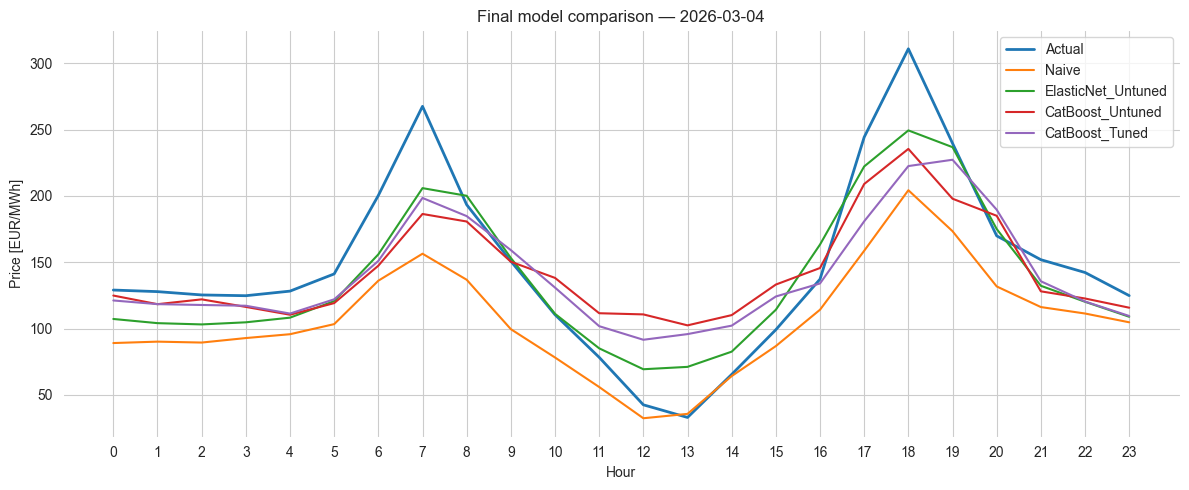

In [91]:
# Select one day from the test set for visual comparison
day = "2026-03-04"

# Create a DataFrame with actual values and selected model predictions for that day
plot_df = pd.DataFrame({
    "actual": Y_test.loc[day].values,
    "naive": Y_test_naive.loc[day].values,
    "ElasticNet_Untuned": Y_test_pred_enet.loc[day].values,
    "CatBoost_Untuned": Y_test_pred_cat.loc[day].values,
    "CatBoost_Tuned": Y_test_pred_cat_tuned.loc[day].values
})

# Create an hour axis from 0 to 23
plot_df["hour"] = range(24)

# Plot actual values and selected model forecasts
plt.figure(figsize=(12, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.plot(plot_df["hour"], plot_df["ElasticNet_Untuned"], label="ElasticNet_Untuned")
plt.plot(plot_df["hour"], plot_df["CatBoost_Untuned"], label="CatBoost_Untuned")
plt.plot(plot_df["hour"], plot_df["CatBoost_Tuned"], label="CatBoost_Tuned")

# Add labels and formatting
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Final model comparison — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()